# 🍔 Poder de Compra e Saúde Mental no Brasil (2014–2020)
### Uma análise entre rendimento domiciliar, custo de vida e consumo de psicofármacos

**Aluno:** Marcelo Monnerat Castello  
**Disciplina:** Sprint: Análise de Dados e Boas Práticas  
**PUC-Rio — 2026**

---

## 1. Definição do Problema

### 📌 Descrição do problema

O Brasil é um dos países com maior prevalência de transtornos de ansiedade
do mundo. Ao mesmo tempo, o custo de vida medido pelo Big Mac Index e a
queda do rendimento domiciliar per capita sugerem perda de poder de compra
do trabalhador brasileiro ao longo dos anos.

**Pergunta central:**
> Existe relação entre a perda de poder de compra do trabalhador brasileiro
> e o aumento no consumo de psicofármacos (ansiolíticos e antidepressivos)
> entre 2014 e 2020?

---

### 📌 Tipo de problema

Este é um problema **não supervisionado** — não há variável alvo a prever.  
O objetivo é **explorar padrões e correlações** entre as variáveis econômicas
e de saúde mental ao longo do tempo.

---

### 📌 Premissas e hipóteses

- O aumento do custo de vida (medido pelo Big Mac Index) combinado com a
  queda do rendimento domiciliar representa perda de poder de compra.
- A perda de poder de compra é um fator de estresse que pode contribuir
  para o aumento do consumo de psicofármacos.
- O consumo de ansiolíticos e antidepressivos é usado como proxy para
  prevalência de transtornos de ansiedade e depressão na população.

---

### 📌 Restrições e condições para seleção dos dados

- Período: **2014 a 2020** (limitado pela disponibilidade do dataset ANVISA/SNGPC)
- País: **Brasil**
- Medicamentos: apenas **ansiolíticos, antidepressivos e antipsicóticos/estabilizadores**
- Dados de venda de medicamentos referem-se apenas a **farmácias privadas**
  registradas no SNGPC — farmácias públicas não estão incluídas.
- O CID10 foi descartado pois apresentou menos de 1,3% de preenchimento
  em todos os anos analisados.

---

### 📌 Datasets utilizados

| # | Dataset | Fonte | Período |
|---|---|---|---|
| 1 | Big Mac Index | The Economist / Kaggle | 2000–2024 |
| 2 | Rendimento domiciliar per capita médio | IPEA / SIS-IBGE | 2012–2024 |
| 3 | Prevalência de transtornos de ansiedade | Our World in Data / IHME | 1990–2023 |
| 4 | Venda de psicofármacos | ANVISA / SNGPC via Base dos Dados | 2014–2020 |

In [ ]:
# ============================================================
# Importação de bibliotecas
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

# Configurações visuais padrão
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print("✅ Bibliotecas carregadas com sucesso!")
print(f"   pandas     {pd.__version__}")
print(f"   numpy      {np.__version__}")
print(f"   matplotlib {plt.matplotlib.__version__}")
print(f"   seaborn    {sns.__version__}")

✅ Bibliotecas carregadas com sucesso!
   pandas     2.2.2
   numpy      2.0.2
   matplotlib 3.10.0
   seaborn    0.13.2


## 2. Carregamento dos Dados

Os datasets são lidos diretamente das URLs raw do repositório público no GitHub,
garantindo que o notebook seja reprodutível por qualquer pessoa sem necessidade
de uploads locais.

---

### 📦 Dataset 1 — Big Mac Index
**Fonte:** The Economist, disponível no Kaggle  
**Link:** https://www.kaggle.com/datasets/paultimothymooney/the-economists-big-mac-index  
**Arquivo:** `big-mac-source-data-v2.csv`  
**Descrição:** Preço do Big Mac em moeda local e em dólar para ~50 países,
com frequência semestral desde 2000.

---

### 📦 Dataset 2 — Rendimento Domiciliar Per Capita Médio
**Fonte:** IPEA / SIS-IBGE (PNAD Contínua)  
**Link:** https://ipeadata.gov.br  
**Arquivo:** `ipeadata-rendimento-domiciliar-per-capita-medio.csv`  
**Descrição:** Rendimento domiciliar per capita médio anual do Brasil em R$,
de 2012 a 2024.

---

### 📦 Dataset 3 — Prevalência de Transtornos de Ansiedade no Brasil
**Fonte:** Our World in Data / IHME Global Burden of Disease (2025)  
**Link:** https://ourworldindata.org/grapher/anxiety-disorders-prevalence  
**Arquivo:** `anxiety_brazil.csv`  
**Descrição:** Estimativa anual do percentual da população brasileira com
transtornos de ansiedade, de 1990 a 2023. Os dados foram extraídos do
gráfico SVG oficial do Our World in Data, cujos valores estão codificados
nas coordenadas dos pontos do gráfico.

---

### 📦 Dataset 4 — Venda de Psicofármacos (ANVISA/SNGPC)
**Fonte:** ANVISA — Sistema Nacional de Gerenciamento de Produtos Controlados,  
disponível via Base dos Dados (BigQuery)  
**Link BigQuery:** https://basedosdados.org/dataset/bd52ab08-9980-4831-a88c-a1ac5226ef27  

**Query executada no BigQuery para geração do CSV:**
```sql
SELECT
  ano,
  mes,
  sexo,
  CASE
    WHEN SAFE_CAST(idade AS INT64) BETWEEN 0 AND 17 THEN 'CRIANCA_ADOLESCENTE'
    WHEN SAFE_CAST(idade AS INT64) BETWEEN 18 AND 24 THEN 'JOVEM_ADULTO'
    WHEN SAFE_CAST(idade AS INT64) BETWEEN 25 AND 59 THEN 'ADULTO_TRABALHADOR'
    WHEN SAFE_CAST(idade AS INT64) >= 60 THEN 'IDOSO'
    ELSE 'NAO_INFORMADO'
  END AS faixa_etaria,
  CASE
    WHEN principio_ativo IN (
      'CLORIDRATO DE FLUOXETINA','CLORIDRATO DE SERTRALINA',
      'OXALATO DE ESCITALOPRAM','CLORIDRATO DE PAROXETINA',
      'CLORIDRATO DE VENLAFAXINA','CLORIDRATO DE DULOXETINA',
      'CLORIDRATO DE BUPROPIONA','MIRTAZAPINA',
      'CLORIDRATO DE AMITRIPTILINA','CLORIDRATO DE NORTRIPTILINA',
      'CLORIDRATO DE TRAZODONA','BROMIDRATO DE CITALOPRAM',
      'SUCCINATO DE DESVENLAFAXINA MONOIDRATADO',
      'CLORIDRATO DE CLOMIPRAMINA','CLORIDRATO DE IMIPRAMINA','CITALOPRAM'
    ) THEN 'ANTIDEPRESSIVO'
    WHEN principio_ativo IN (
      'CLONAZEPAM','ALPRAZOLAM','DIAZEPAM','BROMAZEPAM',
      'LORAZEPAM','CLOBAZAM','FLUNITRAZEPAM','NITRAZEPAM',
      'CLORIDRATO DE FLURAZEPAM','ESTAZOLAM','MIDAZOLAM',
      'MALEATO DE MIDAZOLAM','HEMITARTARATO DE ZOLPIDEM',
      'CLORIDRATO DE BUSPIRONA','ESZOPICLONA'
    ) THEN 'ANSIOLITICO'
    WHEN principio_ativo IN (
      'RISPERIDONA','HEMIFUMARATO DE QUETIAPINA','OLANZAPINA',
      'HALOPERIDOL','CLORIDRATO DE CLORPROMAZINA',
      'MALEATO DE LEVOMEPROMAZINA','PERICIAZINA','CARBONATO DE LÍTIO',
      'DIVALPROATO DE SÓDIO','VALPROATO DE SÓDIO','LAMOTRIGINA'
    ) THEN 'ANTIPSICÓTICO_ESTABILIZADOR'
  END AS categoria,
  SUM(quantidade_vendida) AS total_vendido
FROM `basedosdados.br_anvisa_medicamentos_industrializados.microdados`
WHERE
  ano BETWEEN 2014 AND 2020
  AND quantidade_vendida IS NOT NULL
  AND quantidade_vendida > 0
  AND sexo IS NOT NULL
  AND idade IS NOT NULL
  AND principio_ativo IN (
    'CLORIDRATO DE FLUOXETINA','CLORIDRATO DE SERTRALINA',
    'OXALATO DE ESCITALOPRAM','CLORIDRATO DE PAROXETINA',
    'CLORIDRATO DE VENLAFAXINA','CLORIDRATO DE DULOXETINA',
    'CLORIDRATO DE BUPROPIONA','MIRTAZAPINA',
    'CLORIDRATO DE AMITRIPTILINA','CLORIDRATO DE NORTRIPTILINA',
    'CLORIDRATO DE TRAZODONA','BROMIDRATO DE CITALOPRAM',
    'SUCCINATO DE DESVENLAFAXINA MONOIDRATADO',
    'CLORIDRATO DE CLOMIPRAMINA','CLORIDRATO DE IMIPRAMINA','CITALOPRAM',
    'CLONAZEPAM','ALPRAZOLAM','DIAZEPAM','BROMAZEPAM',
    'LORAZEPAM','CLOBAZAM','FLUNITRAZEPAM','NITRAZEPAM',
    'CLORIDRATO DE FLURAZEPAM','ESTAZOLAM','MIDAZOLAM',
    'MALEATO DE MIDAZOLAM','HEMITARTARATO DE ZOLPIDEM',
    'CLORIDRATO DE BUSPIRONA','ESZOPICLONA',
    'RISPERIDONA','HEMIFUMARATO DE QUETIAPINA','OLANZAPINA',
    'HALOPERIDOL','CLORIDRATO DE CLORPROMAZINA',
    'MALEATO DE LEVOMEPROMAZINA','PERICIAZINA','CARBONATO DE LÍTIO',
    'DIVALPROATO DE SÓDIO','VALPROATO DE SÓDIO','LAMOTRIGINA'
  )
GROUP BY ano, mes, sexo, faixa_etaria, categoria
ORDER BY ano, mes, sexo, faixa_etaria, categoria ASC
```

**Arquivo gerado:** `anvisa_psicofarmacos.csv`  
**Descrição:** Total mensal de unidades vendidas de psicofármacos no Brasil,
agrupados em 3 categorias clínicas: Ansiolíticos, Antidepressivos e
Antipsicóticos/Estabilizadores. Período: 2014–2020.

In [ ]:
# ============================================================
# Carregamento dos datasets via GitHub raw URL
# ============================================================

BASE_URL = "https://raw.githubusercontent.com/MonneratRJ/mvp-bigmac-index/refs/heads/master/data/"

# --- Dataset 1: Big Mac Index ---
df_bigmac = pd.read_csv(BASE_URL + "big-mac-source-data-v2.csv")
print(f"✅ Big Mac Index:        {df_bigmac.shape[0]:>6} linhas x {df_bigmac.shape[1]} colunas")

# --- Dataset 2: Rendimento domiciliar (IPEA) ---
df_renda_raw = pd.read_csv(
    BASE_URL + "ipeadata-rendimento-domiciliar-per-capita-medio.csv",
    sep=';',
    encoding='latin1',
    skiprows=1
)

# O arquivo original tem os anos como colunas — transpondo para formato vertical
anos = [str(a) for a in range(2012, 2025)]
valores = df_renda_raw[anos].values[0]

df_renda = pd.DataFrame({
    'ano': [int(a) for a in anos],
    'rendimento_medio': [float(str(v).replace(',', '.')) for v in valores]
})

print(f"✅ Rendimento domiciliar:  {df_renda.shape[0]:>4} linhas x {df_renda.shape[1]} colunas")

# --- Dataset 3: Ansiedade Brasil ---
df_ansiedade = pd.read_csv(BASE_URL + "anxiety_brazil.csv")
print(f"✅ Ansiedade Brasil:     {df_ansiedade.shape[0]:>6} linhas x {df_ansiedade.shape[1]} colunas")

# --- Dataset 4: ANVISA psicofármacos ---
df_anvisa = pd.read_csv(BASE_URL + "anvisa_psicofarmacos.csv")
print(f"✅ ANVISA psicofármacos: {df_anvisa.shape[0]:>6} linhas x {df_anvisa.shape[1]} colunas")

✅ Big Mac Index:          2302 linhas x 8 colunas
✅ Rendimento domiciliar:    13 linhas x 2 colunas
✅ Ansiedade Brasil:         34 linhas x 2 colunas
✅ ANVISA psicofármacos:   2016 linhas x 6 colunas


## 3. Análise Exploratória dos Dados

O objetivo desta etapa é entender a estrutura, qualidade e distribuição
dos dados antes de qualquer transformação. Para cada dataset verificamos:
- Tipos de dados e primeiras linhas
- Valores faltantes e inconsistências
- Estatísticas descritivas
- Distribuições e visualizações

In [ ]:
# ============================================================
# Inspeção inicial — Big Mac Index
# ============================================================

print("=== TIPOS DE DADOS ===")
print(df_bigmac.dtypes)
print(f"\n=== PRIMEIRAS LINHAS ===")
df_bigmac.head()

=== TIPOS DE DADOS ===
name              object
iso_a3            object
currency_code     object
local_price      float64
dollar_ex        float64
GDP_dollar       float64
GDP_local        float64
date              object
dtype: object

=== PRIMEIRAS LINHAS ===


,name,iso_a3,currency_code,local_price,dollar_ex,GDP_dollar,GDP_local,date
0,Argentina,ARG,ARS,2.50,1.00,9283.175,9283.175,2000-04-01
1,Australia,AUS,AUD,2.59,1.68,20394.027,32402.454,2000-04-01
2,Brazil,BRA,BRL,2.95,1.79,5123.549,5941.865,2000-04-01
3,Canada,CAN,CAD,2.85,1.47,21046.556,31222.677,2000-04-01
4,Switzerland,CHE,CHF,5.90,1.70,42737.474,61961.359,2000-04-01


In [ ]:
# ============================================================
# Qualidade dos dados — Big Mac Index
# ============================================================

print("=== VALORES FALTANTES ===")
print(df_bigmac.isnull().sum())

print(f"\n=== ESTATÍSTICAS DESCRITIVAS ===")
df_bigmac.describe()

=== VALORES FALTANTES ===
name              0
iso_a3            0
currency_code     0
local_price       0
dollar_ex         0
GDP_dollar        1
GDP_local        23
date              0
dtype: int64

=== ESTATÍSTICAS DESCRITIVAS ===


,local_price,dollar_ex,GDP_dollar,GDP_local
count,2.302000e+03,2.302000e+03,2301.000000,2.279000e+03
mean,1.456318e+04,4.269353e+03,25216.017568,3.033448e+06
std,3.627712e+05,9.260286e+04,21940.363320,1.349078e+07
min,0.000000e+00,0.000000e+00,572.090000,3.614900e+01
25%,4.612500e+00,1.000000e+00,6498.573000,3.264033e+04
50%,1.600000e+01,5.160025e+00,18626.981000,6.947611e+04
75%,9.500000e+01,3.312885e+01,41641.617000,3.406452e+05
max,1.602000e+07,3.613989e+06,108438.547000,3.905034e+08


### 📊 Observações — Big Mac Index

**Estrutura:** 2.302 registros cobrindo ~50 países desde 2000, com 8 atributos.

**Valores faltantes:** GDP_dollar (1 nulo) e GDP_local (23 nulos) — colunas
que não serão usadas na análise principal, então não representam problema.

**Atenção nos dados:** os valores de `local_price` e `dollar_ex` têm desvio
padrão enormes (média muito distante da mediana), o que indica presença de
países com moedas muito desvalorizadas (como Venezuela e Argentina) que
distorcem a escala. O valor mínimo de 0.0 em `local_price` e `dollar_ex`
também merece investigação — pode ser dado ausente registrado como zero.

**Para nossa análise** vamos filtrar apenas o Brasil (`iso_a3 == 'BRA'`) e
trabalhar com `dollar_price`, que será calculada como `local_price / dollar_ex`.

In [ ]:
# Verificar registros com local_price ou dollar_ex igual a zero
zeros = df_bigmac[(df_bigmac['local_price'] == 0) | (df_bigmac['dollar_ex'] == 0)]
print(f"Registros com valor zero: {len(zeros)}")
print(zeros[['name', 'date', 'local_price', 'dollar_ex']])

Registros com valor zero: 1
           name        date  local_price  dollar_ex
1295  Venezuela  2018-01-01          0.0        0.0


### 📊 Observações — Zeros e outliers

Foi identificado **1 registro com valor zero**: Venezuela em janeiro de 2018.
Isso coincide com o período de hiperinflação extrema do país, que
impossibilitou o registro confiável do preço. Este registro será removido
no pré-processamento.

Como nosso foco é o Brasil, esse registro não afeta nossa análise diretamente,
mas é importante documentar a inconsistência encontrada.

In [ ]:
# Filtrar apenas Brasil e calcular preço em dólar
df_brasil = df_bigmac[df_bigmac['iso_a3'] == 'BRA'].copy()
df_brasil['date'] = pd.to_datetime(df_brasil['date'])
df_brasil['dollar_price'] = df_brasil['local_price'] / df_brasil['dollar_ex']
df_brasil['ano'] = df_brasil['date'].dt.year

print(f"Registros do Brasil: {len(df_brasil)}")
print(f"Período: {df_brasil['date'].min().date()} até {df_brasil['date'].max().date()}")
print(f"\nPreço do Big Mac no Brasil (em dólar):")
print(df_brasil[['date', 'local_price', 'dollar_price']].to_string(index=False))

Registros do Brasil: 42
Período: 2000-04-01 até 2025-01-01

Preço do Big Mac no Brasil (em dólar):
      date  local_price  dollar_price
2000-04-01         2.95      1.648045
2001-04-01         3.60      1.643836
2002-04-01         3.60      1.538462
2003-04-01         4.55      1.482085
2004-05-01         5.40      1.698113
2005-06-01         5.90      2.393703
2006-01-01         6.20      2.741543
2006-05-01         6.40      2.777175
2007-01-01         6.40      2.999766
2007-06-01         6.90      3.606900
2008-06-01         7.50      4.733056
2009-07-01         8.03      4.020830
2010-01-01         8.20      4.758313
2010-07-01         8.71      4.907180
2011-07-01         9.50      6.162429
2012-01-01        10.25      5.678670
2012-07-01        10.08      4.935974
2013-01-01        11.25      5.643766
2013-07-01        12.00      5.284830
2014-01-01        12.40      5.247456
2014-07-01        13.00      5.855196
2015-01-01        13.50      5.206827
2015-07-01        13.50    

### 📊 Evolução do preço do Big Mac no Brasil

Observando os dados do Brasil (42 registros de 2000 a 2025), já é possível
identificar padrões interessantes antes mesmo de visualizar:

- O preço em **reais** subiu continuamente: de R\$ 2,95 em 2000 para R\$ 23,90
  em 2025 — um aumento de **710%**
- O preço em **dólares** conta uma história diferente: chegou ao pico de
  US\$ 6,16 em 2011 e nunca mais voltou a esse nível
- A queda brusca para US\$ 3,35 em janeiro de 2016 coincide com a crise econômica
- O período 2022–2025 mostra estabilidade no preço em reais mas oscilação
  em dólar por conta do câmbio

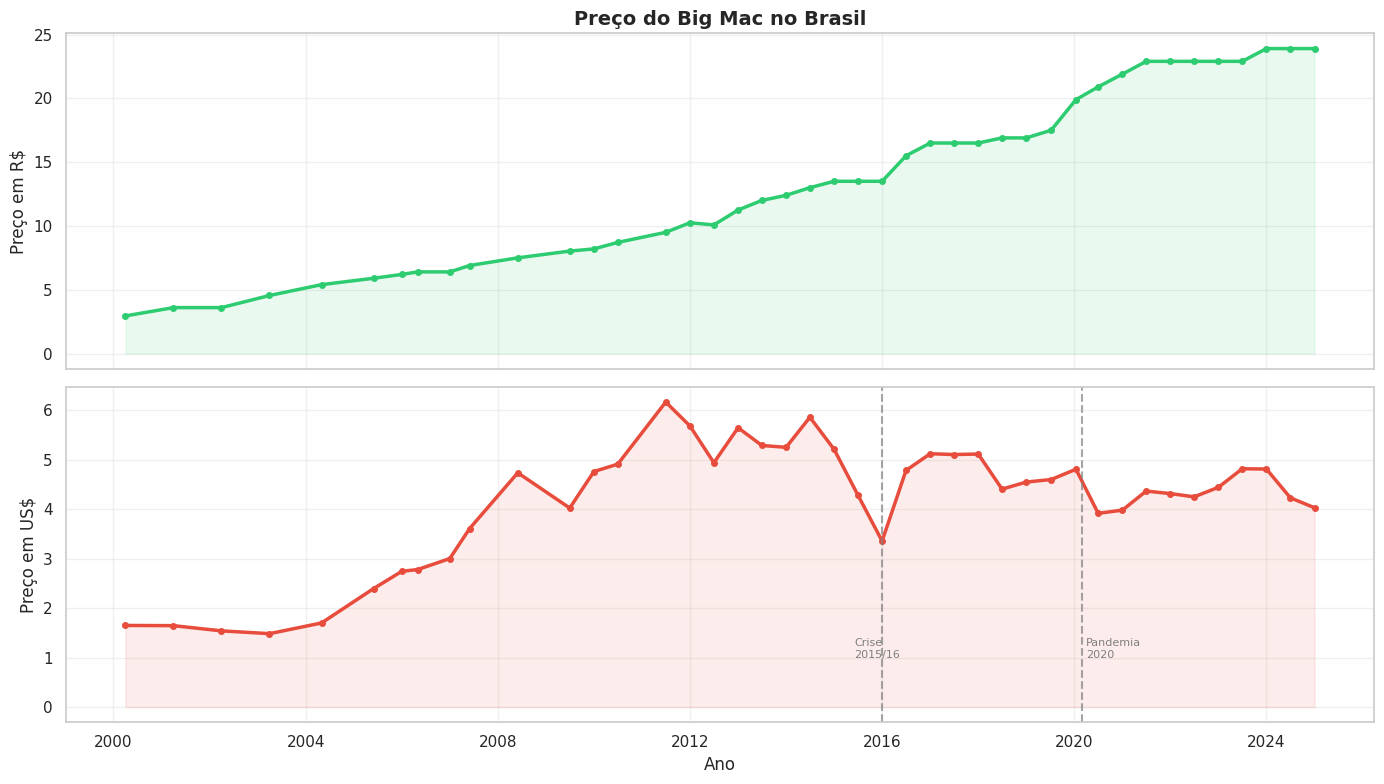

In [ ]:
# ============================================================
# Gráfico 1 — Evolução do preço do Big Mac no Brasil
# ============================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Preço em reais
ax1.plot(df_brasil['date'], df_brasil['local_price'],
         color='#2ecc71', linewidth=2.5, marker='o', markersize=4)
ax1.set_title('Preço do Big Mac no Brasil', fontsize=14, fontweight='bold')
ax1.set_ylabel('Preço em R$')
ax1.fill_between(df_brasil['date'], df_brasil['local_price'], alpha=0.1, color='#2ecc71')
ax1.grid(True, alpha=0.3)

# Preço em dólar
ax2.plot(df_brasil['date'], df_brasil['dollar_price'],
         color='#e74c3c', linewidth=2.5, marker='o', markersize=4)
ax2.set_ylabel('Preço em US$')
ax2.set_xlabel('Ano')
ax2.fill_between(df_brasil['date'], df_brasil['dollar_price'], alpha=0.1, color='#e74c3c')
ax2.grid(True, alpha=0.3)

# Marcando eventos importantes
ax2.axvline(pd.Timestamp('2016-01-01'), color='gray', linestyle='--', alpha=0.7)
ax2.axvline(pd.Timestamp('2020-03-01'), color='gray', linestyle='--', alpha=0.7)
ax2.text(pd.Timestamp('2015-06-01'), 1.0, 'Crise\n2015/16', fontsize=8, color='gray')
ax2.text(pd.Timestamp('2020-04-01'), 1.0, 'Pandemia\n2020', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

### 📝 Análise — Gráfico 1

O gráfico revela dois comportamentos distintos dependendo da moeda utilizada:

**Em reais:** o preço sobe de forma quase ininterrupta, saindo de R\$ 2,95
em 2000 para R\$ 23,90 em 2025 — um aumento de 710% em 25 anos, reflexo
direto da inflação acumulada no período.

**Em dólares:** o poder de compra do brasileiro em moeda forte atingiu seu
pico em 2011 (US\$ 6,16) e desde então oscila entre US\$ 3,50 e US\$ 5,20.
Dois eventos são claramente visíveis no gráfico:

- A **crise de 2015/2016** causou queda brusca para US\$ 3,35 — o menor
  valor desde 2004
- A **pandemia de 2020** provocou nova queda, seguida de recuperação parcial

Apesar do preço em reais subir sempre, o trabalhador brasileiro perdeu
poder de compra em termos globais ao longo da última década.

### 3.2 Rendimento Domiciliar Per Capita (IPEA)

In [ ]:
# ============================================================
# Inspeção inicial — Rendimento Domiciliar
# ============================================================

print("=== TIPOS DE DADOS ===")
print(df_renda.dtypes)

print(f"\n=== VALORES FALTANTES ===")
print(df_renda.isnull().sum())

print(f"\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(df_renda.describe())

=== TIPOS DE DADOS ===
ano                   int64
rendimento_medio    float64
dtype: object

=== VALORES FALTANTES ===
ano                 0
rendimento_medio    0
dtype: int64

=== ESTATÍSTICAS DESCRITIVAS ===
              ano  rendimento_medio
count    13.00000         13.000000
mean   2018.00000       1709.322208
std       3.89444        115.958924
min    2012.00000       1551.223631
25%    2015.00000       1657.795482
50%    2018.00000       1672.575444
75%    2021.00000       1726.917733
max    2024.00000       2019.143278


### 📊 Observações — Rendimento Domiciliar

Dataset simples e limpo: 13 registros anuais de 2012 a 2024, sem valores
faltantes.

Points de atenção nas estatísticas:
- A **média** de R\$ 1.709 está acima da **mediana** de R\$ 1.672, indicando
  que os anos mais recentes (com valores mais altos) puxam a média para cima
- O **mínimo** de R\$ 1.551 ocorreu em 2021 — fundo do poço pós-pandemia
- O **máximo** de R\$ 2.019 em 2024 representa a recuperação recente
- O desvio padrão de R\$ 115 é relativamente pequeno, indicando que o
  rendimento não oscilou drasticamente ao longo do período

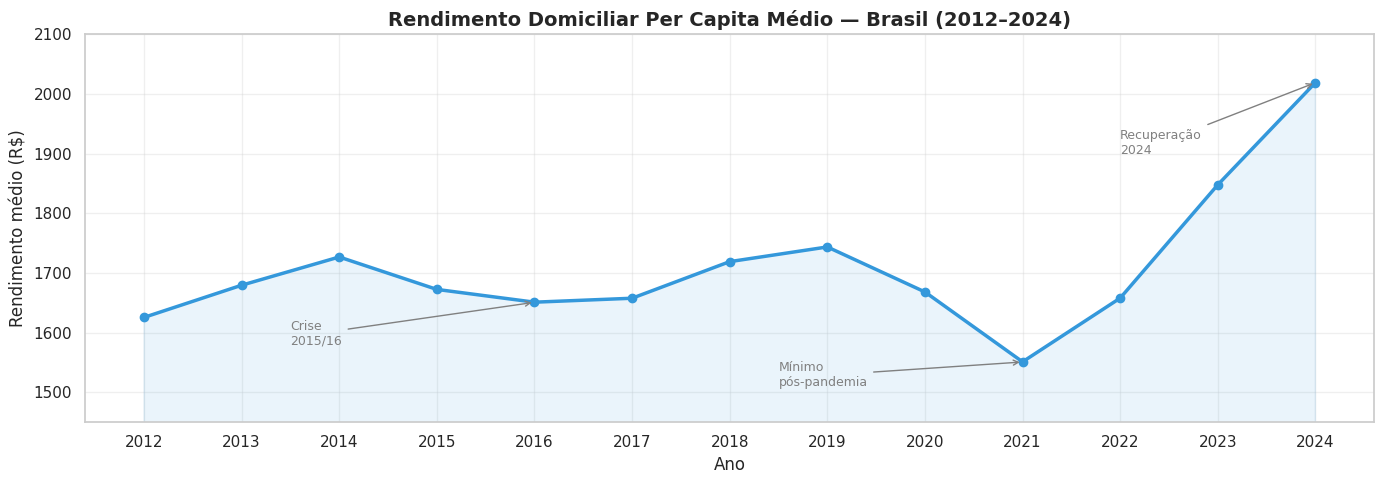

In [ ]:
# ============================================================
# Gráfico 2 — Evolução do rendimento domiciliar per capita
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_renda['ano'], df_renda['rendimento_medio'],
        color='#3498db', linewidth=2.5, marker='o', markersize=6)
ax.fill_between(df_renda['ano'], df_renda['rendimento_medio'],
                alpha=0.1, color='#3498db')

# Anotando pontos importantes
ax.annotate('Crise\n2015/16', xy=(2016, 1651), xytext=(2013.5, 1580),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
ax.annotate('Mínimo\npós-pandemia', xy=(2021, 1551), xytext=(2018.5, 1510),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
ax.annotate('Recuperação\n2024', xy=(2024, 2019), xytext=(2022, 1900),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')

ax.set_title('Rendimento Domiciliar Per Capita Médio — Brasil (2012–2024)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Rendimento médio (R$)')
ax.set_xticks(df_renda['ano'])
ax.grid(True, alpha=0.3)
ax.set_ylim(1450, 2100)

plt.tight_layout()
plt.show()

### 3.3 Comparativo Big Mac Index — América Latina (2000–2025)

Usando o preço do Big Mac em dólar como proxy de poder de compra,
comparamos o Brasil com seus vizinhos latino-americanos ao longo de 25 anos.
Todos os 5 países têm 42 registros, exceto a Colômbia (37), que entrou
no índice um pouco mais tarde.

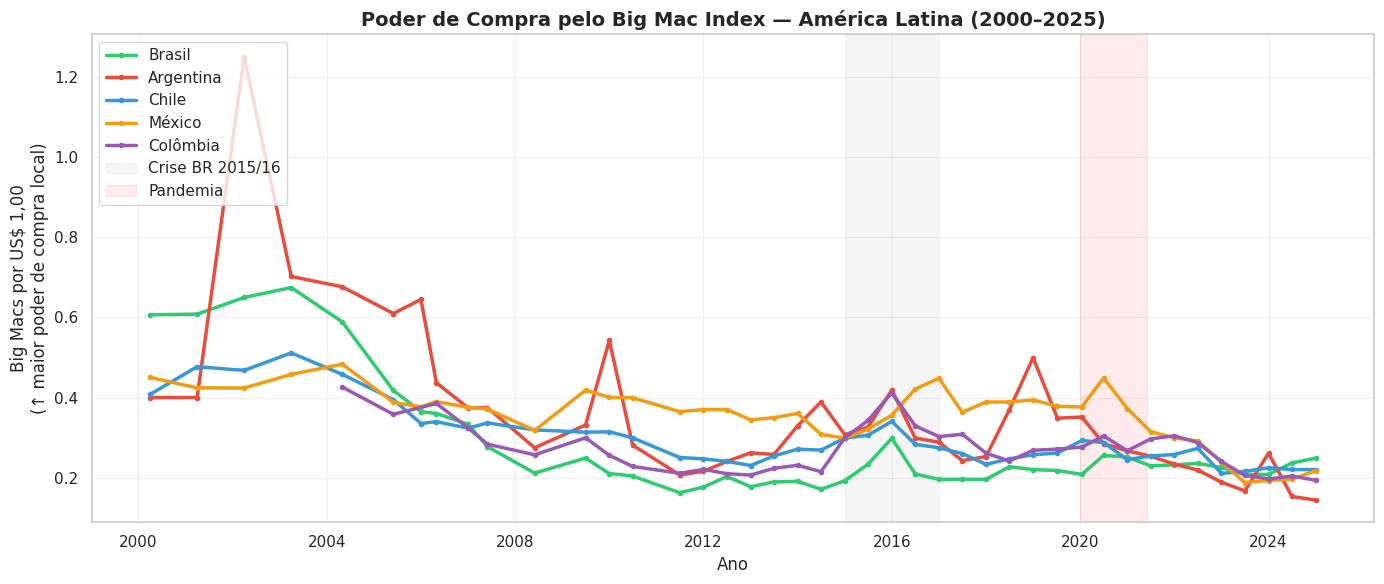

In [ ]:
# ============================================================
# Gráfico 3 — Big Mac Index: Poder de Compra — América Latina
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

for pais in paises_latam:
    dados = df_latam[df_latam['iso_a3'] == pais].sort_values('date')
    poder_compra = 1 / dados['dollar_price']  # Big Macs por dólar
    ax.plot(dados['date'], poder_compra,
            color=cores[pais], linewidth=2.5, marker='o',
            markersize=3, label=nomes[pais])

# Marcando eventos importantes
ax.axvspan(pd.Timestamp('2015-01-01'), pd.Timestamp('2017-01-01'),
           alpha=0.08, color='gray', label='Crise BR 2015/16')
ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
           alpha=0.08, color='red', label='Pandemia')

ax.set_title('Poder de Compra pelo Big Mac Index — América Latina (2000–2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Big Macs por US$ 1,00\n(↑ maior poder de compra local)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📝 Análise — Gráfico 3

Neste gráfico, **linha mais alta = maior poder de compra local**: quanto
mais Big Macs se consegue comprar com US\$ 1,00, mais barato ele é para
o consumidor local. Essa inversão muda completamente a narrativa.

O **Brasil (verde)** ocupa sistematicamente as posições mais baixas da
região ao longo de quase todo o período — ou seja, o trabalhador brasileiro
precisa de mais dólares para comprar o mesmo sanduíche que seus vizinhos.
O pico de preço em dólar entre 2008 e 2014, que no gráfico anterior parecia
uma posição de destaque, revela aqui seu verdadeiro significado: o real
valorizado encareceu o produto para o consumidor local sem que isso
representasse ganho real de poder de compra.

O **México (laranja)** lidera o poder de compra na maior parte do período
— cada dólar rende mais lá do que em qualquer outro país da amostra. O
crescimento recente, possivelmente impulsionado pelo fenômeno do nearshoring
pós-pandemia, começa a corroer essa vantagem.

A **Argentina (vermelho)** apresenta a trajetória mais errática — reflexo
direto de suas sucessivas crises cambiais. O salto para quase US\$ 7,00
em 2025 aparece aqui como uma queda expressiva no poder de compra,
evidenciando o custo real da instabilidade econômica para o consumidor
argentino.

**Chile e Colômbia (azul e roxo)** mantêm trajetórias estáveis e
consistentemente acima do Brasil, sugerindo economias com menor volatilidade
cambial e melhor equilíbrio entre preços e renda ao longo do período.

Durante a **pandemia (área vermelha)**, as desvalorizações cambiais regionais
geraram uma alta temporária no poder de compra em vários países — cada
dólar passou a comprar mais. Essa vantagem, porém, se dissipou rapidamente
com a recuperação econômica e a valorização das moedas locais.

### 3.4 Prevalência de Transtornos de Ansiedade no Brasil (1990–2023)

In [ ]:
# ============================================================
# Inspeção inicial — Ansiedade Brasil
# ============================================================

print("=== TIPOS DE DADOS ===")
print(df_ansiedade.dtypes)

print(f"\n=== VALORES FALTANTES ===")
print(df_ansiedade.isnull().sum())

print(f"\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(df_ansiedade.describe())

=== TIPOS DE DADOS ===
year                        int64
anxiety_prevalence_pct    float64
dtype: object

=== VALORES FALTANTES ===
year                      0
anxiety_prevalence_pct    0
dtype: int64

=== ESTATÍSTICAS DESCRITIVAS ===
              year  anxiety_prevalence_pct
count    34.000000               34.000000
mean   2006.500000                7.675974
std       9.958246                1.461036
min    1990.000000                5.784300
25%    1998.250000                6.688200
50%    2006.500000                7.590650
75%    2014.750000                8.126925
max    2023.000000               12.396200


### 📊 Observações — Prevalência de Ansiedade

Dataset limpo: 34 registros anuais de 1990 a 2023, sem valores faltantes.

Points de atenção:
- A prevalência **mais que dobrou** no período: de 5,78% em 1990 para
  12,40% em 2023
- A **mediana de 7,59%** está bem abaixo da **média de 7,68%**, indicando
  que os valores extremos recentes (pandemia) puxam a média para cima
- O salto mais expressivo ocorre a partir de 2020, onde o desvio em relação
  à tendência histórica é claramente visível
- **Importante:** esses dados são estimativas do IHME baseadas em modelagem
  estatística, não diagnósticos diretos. Representam a prevalência esperada
  na população, independente de diagnóstico formal.

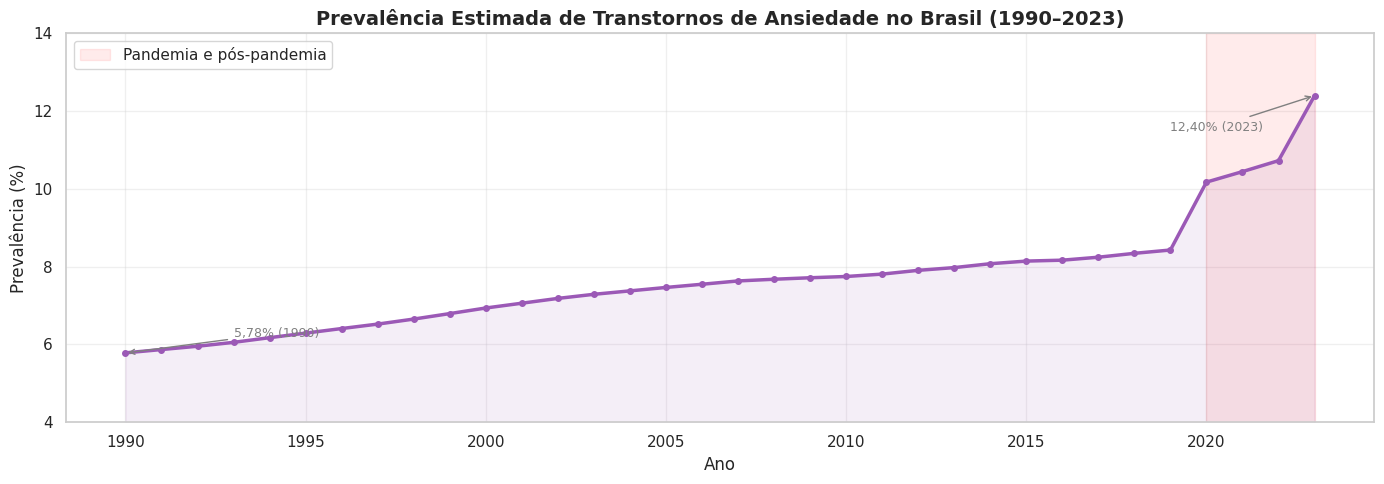

In [ ]:
# ============================================================
# Gráfico 4 — Prevalência de ansiedade no Brasil
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_ansiedade['year'], df_ansiedade['anxiety_prevalence_pct'],
        color='#9b59b6', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(df_ansiedade['year'], df_ansiedade['anxiety_prevalence_pct'],
                alpha=0.1, color='#9b59b6')

ax.axvspan(2020, 2023, alpha=0.08, color='red', label='Pandemia e pós-pandemia')

ax.annotate('5,78% (1990)', xy=(1990, 5.78), xytext=(1993, 6.2),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
ax.annotate('12,40% (2023)', xy=(2023, 12.40), xytext=(2019, 11.5),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')

ax.set_title('Prevalência Estimada de Transtornos de Ansiedade no Brasil (1990–2023)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Prevalência (%)')
ax.set_ylim(4, 14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📝 Análise — Gráfico 4

A prevalência estimada de ansiedade no Brasil cresceu de forma consistente
ao longo de 33 anos, saindo de 5,78% em 1990 para 12,40% em 2023 — um
aumento de **114%**.

O crescimento foi gradual até 2019, com uma aceleração expressiva a partir
de 2020, coincidindo com a pandemia de COVID-19. Este dataset será usado
como **referência de validação** para os dados de venda de psicofármacos
da ANVISA — se as duas séries apontarem na mesma direção, isso fortalece
a consistência da análise.

### 3.5 Venda de Psicofármacos — ANVISA/SNGPC (2014–2020)

In [ ]:
# ============================================================
# Inspeção inicial — ANVISA Psicofármacos
# ============================================================

print("=== TIPOS DE DADOS ===")
print(df_anvisa.dtypes)

print(f"\n=== VALORES FALTANTES ===")
print(df_anvisa.isnull().sum())

print(f"\n=== CATEGORIAS DISPONÍVEIS ===")
print("Categorias:", df_anvisa['categoria'].unique())
print("Sexos:", df_anvisa['sexo'].unique())
print("Faixas etárias:", df_anvisa['faixa_etaria'].unique())

print(f"\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(df_anvisa.describe())

=== TIPOS DE DADOS ===
ano               int64
mes               int64
sexo              int64
faixa_etaria     object
categoria        object
total_vendido     int64
dtype: object

=== VALORES FALTANTES ===
ano              0
mes              0
sexo             0
faixa_etaria     0
categoria        0
total_vendido    0
dtype: int64

=== CATEGORIAS DISPONÍVEIS ===
Categorias: ['ANSIOLITICO' 'ANTIDEPRESSIVO' 'ANTIPSICÓTICO_ESTABILIZADOR']
Sexos: [1 2]
Faixas etárias: ['ADULTO_TRABALHADOR' 'CRIANCA_ADOLESCENTE' 'IDOSO' 'JOVEM_ADULTO']

=== ESTATÍSTICAS DESCRITIVAS ===
               ano          mes         sexo  total_vendido
count  2016.000000  2016.000000  2016.000000    2016.000000
mean   2017.000000     6.500000     1.500000   26844.938492
std       2.000496     3.452909     0.500124   38930.337901
min    2014.000000     1.000000     1.000000    1420.000000
25%    2015.000000     3.750000     1.000000    6509.750000
50%    2017.000000     6.500000     1.500000   19391.000000
75%    

### 📊 Observações — ANVISA Psicofármacos

Dataset rico e limpo: 2.016 registros mensais de 2014 a 2020, sem valores
faltantes, com 6 atributos.

**Estrutura:** cada linha representa a soma mensal de unidades vendidas para
uma combinação de ano, mês, sexo, faixa etária e categoria de medicamento.

**Codificação do sexo:** o campo `sexo` está como inteiro — 1 e 2.
Será convertido para `Masculino` e `Feminino` no pré-processamento.

**Atenção:** o valor máximo de 876.797 é um outlier identificado anteriormente
— julho de 2018, sexo feminino, adultas trabalhadoras, antidepressivos.
Este valor será investigado e tratado no pré-processamento.

**Desvio padrão elevado** (38.930 vs média de 26.844) confirma a presença
de outliers que distorcem a distribuição — a mediana de 19.391 é um
indicador mais confiável do valor típico.

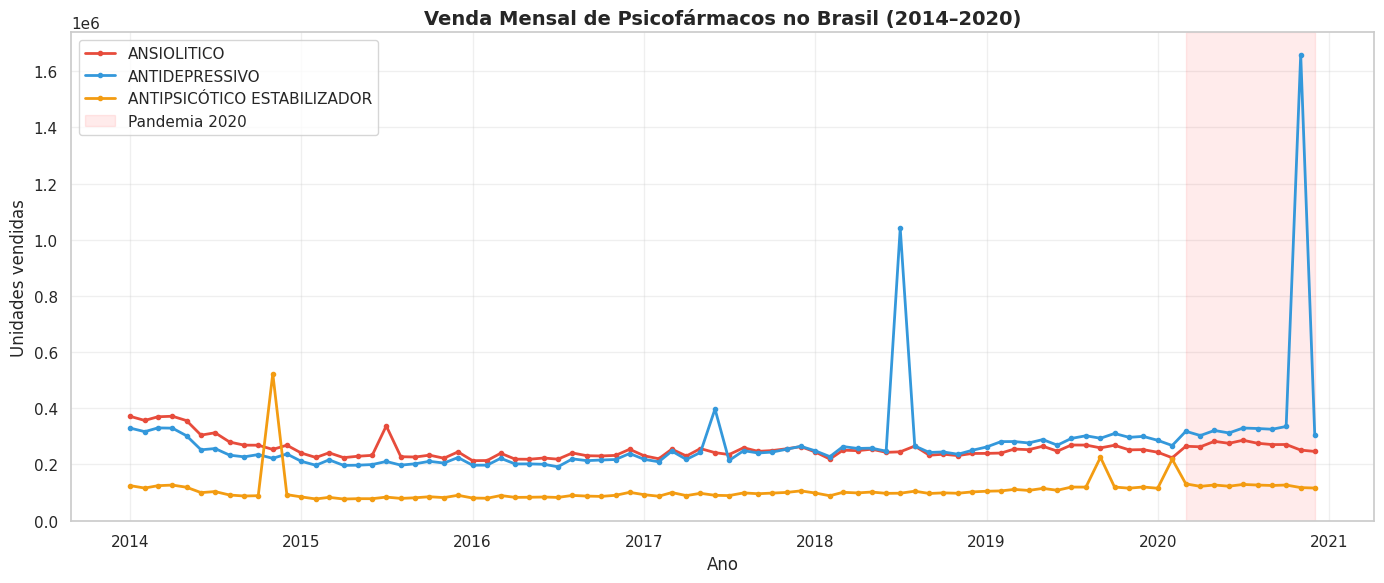

In [ ]:
# ============================================================
# Gráfico 5 — Volume total de vendas por categoria ao longo do tempo
# ============================================================

# Agregar por ano/mês/categoria (somando sexo e faixa etária)
df_anvisa_mensal = df_anvisa.groupby(
    ['ano', 'mes', 'categoria'])['total_vendido'].sum().reset_index()

# Criar coluna de data
df_anvisa_mensal['data'] = pd.to_datetime(
    df_anvisa_mensal['ano'].astype(str) + '-' +
    df_anvisa_mensal['mes'].astype(str) + '-01')

cores_anvisa = {
    'ANSIOLITICO': '#e74c3c',
    'ANTIDEPRESSIVO': '#3498db',
    'ANTIPSICÓTICO_ESTABILIZADOR': '#f39c12'
}

fig, ax = plt.subplots(figsize=(14, 6))

for cat in df_anvisa_mensal['categoria'].unique():
    dados = df_anvisa_mensal[df_anvisa_mensal['categoria'] == cat].sort_values('data')
    ax.plot(dados['data'], dados['total_vendido'],
            color=cores_anvisa[cat], linewidth=2,
            marker='o', markersize=3, label=cat.replace('_', ' '))

ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-01'),
           alpha=0.08, color='red', label='Pandemia 2020')

ax.set_title('Venda Mensal de Psicofármacos no Brasil (2014–2020)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Unidades vendidas')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Registros removidos como outlier: 11
Registros restantes: 241


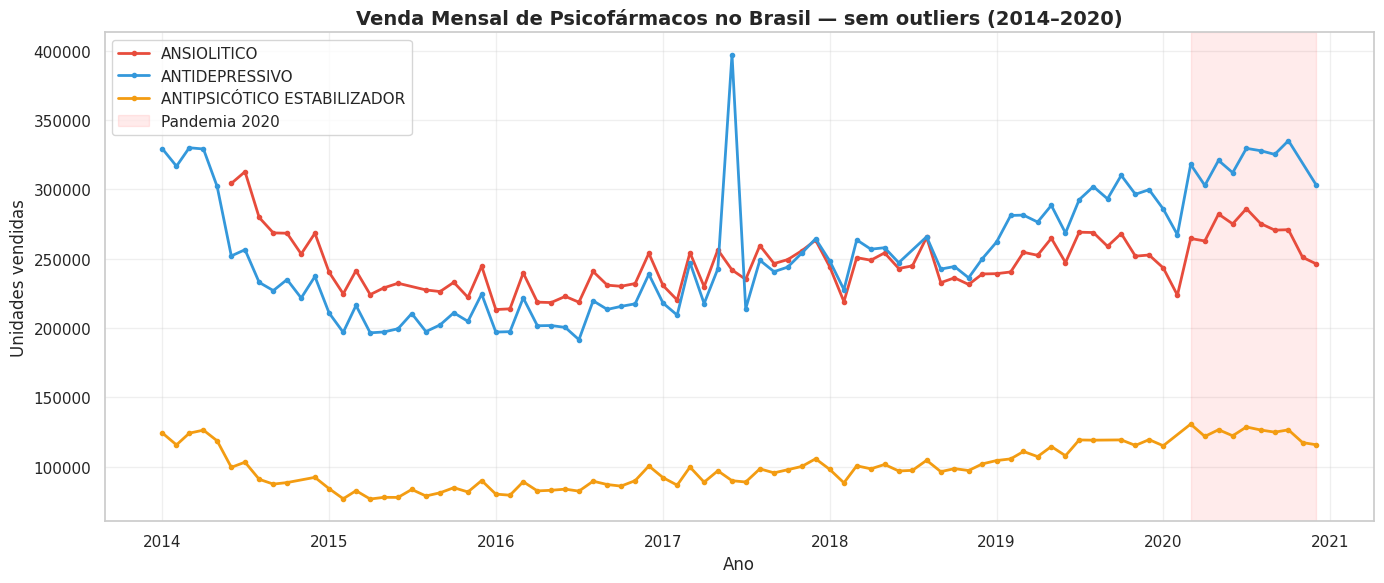

In [ ]:
# ============================================================
# Gráfico 5b — Removendo outliers para ver a tendência real
# ============================================================

# Calcular limite superior (média + 2 desvios padrão por categoria)
def remove_outliers(df, coluna='total_vendido', fator=2):
    resultado = []
    for cat in df['categoria'].unique():
        subset = df[df['categoria'] == cat].copy()
        media = subset[coluna].mean()
        std = subset[coluna].std()
        limite = media + fator * std
        subset_limpo = subset[subset[coluna] <= limite]
        resultado.append(subset_limpo)
    return pd.concat(resultado)

df_anvisa_limpo = remove_outliers(df_anvisa_mensal)

removidos = len(df_anvisa_mensal) - len(df_anvisa_limpo)
print(f"Registros removidos como outlier: {removidos}")
print(f"Registros restantes: {len(df_anvisa_limpo)}")

fig, ax = plt.subplots(figsize=(14, 6))

for cat in df_anvisa_limpo['categoria'].unique():
    dados = df_anvisa_limpo[df_anvisa_limpo['categoria'] == cat].sort_values('data')
    ax.plot(dados['data'], dados['total_vendido'],
            color=cores_anvisa[cat], linewidth=2,
            marker='o', markersize=3, label=cat.replace('_', ' '))

ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-01'),
           alpha=0.08, color='red', label='Pandemia 2020')

ax.set_title('Venda Mensal de Psicofármacos no Brasil — sem outliers (2014–2020)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Unidades vendidas')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📝 Análise — Gráfico 5

Após a remoção de 11 registros outliers (menos de 5% dos dados), a tendência
real de crescimento fica evidente. Três padrões se destacam:

**Queda 2014–2016:** todas as categorias apresentam redução no volume de
vendas, coincidindo com a crise econômica brasileira. Uma hipótese é que
a piora do poder de compra reduziu o acesso a medicamentos controlados,
que têm custo elevado.

**Crescimento 2017–2020:** recuperação consistente em todas as categorias,
com os antidepressivos ultrapassando os ansiolíticos em volume — uma
inversão relevante que sugere mudança no perfil de prescrição psiquiátrica
no Brasil.

**Pandemia 2020:** ao contrário do que se poderia esperar, não há um pico
explosivo visível em 2020 — o crescimento continua, mas de forma gradual.
Isso pode refletir dificuldades de acesso a farmácias durante o lockdown
nos primeiros meses, seguido de normalização.

**Antipsicóticos/Estabilizadores (laranja):** volume consistentemente menor,
mas com crescimento gradual ao longo de todo o período — reflexo do
aumento de diagnósticos de transtorno bipolar e esquizofrenia no Brasil.

**Nota metodológica:** os 11 outliers removidos serão tratados no
pré-processamento pela substituição pela mediana do respectivo
mês/categoria, preservando a continuidade da série temporal.

### 3.6 Poder de Compra do Trabalhador Brasileiro em Horas Trabalhadas

Uma forma concreta e humana de medir o custo de vida é perguntar:
**quantas horas um trabalhador brasileiro precisa trabalhar para comprar
um Big Mac?**

Para isso cruzamos o preço do Big Mac em reais com o rendimento domiciliar
per capita médio do IPEA, assumindo uma jornada padrão de 160 horas mensais.
Quanto maior o número de horas, menor o poder de compra do trabalhador.

> ⚠️ **Nota metodológica:** utilizamos o rendimento domiciliar per capita
> como proxy do salário — uma aproximação que inclui todas as fontes de
> renda da família divididas pelo número de membros. O valor real pode
> variar dependendo do perfil familiar, mas a tendência histórica é válida
> para análise comparativa.

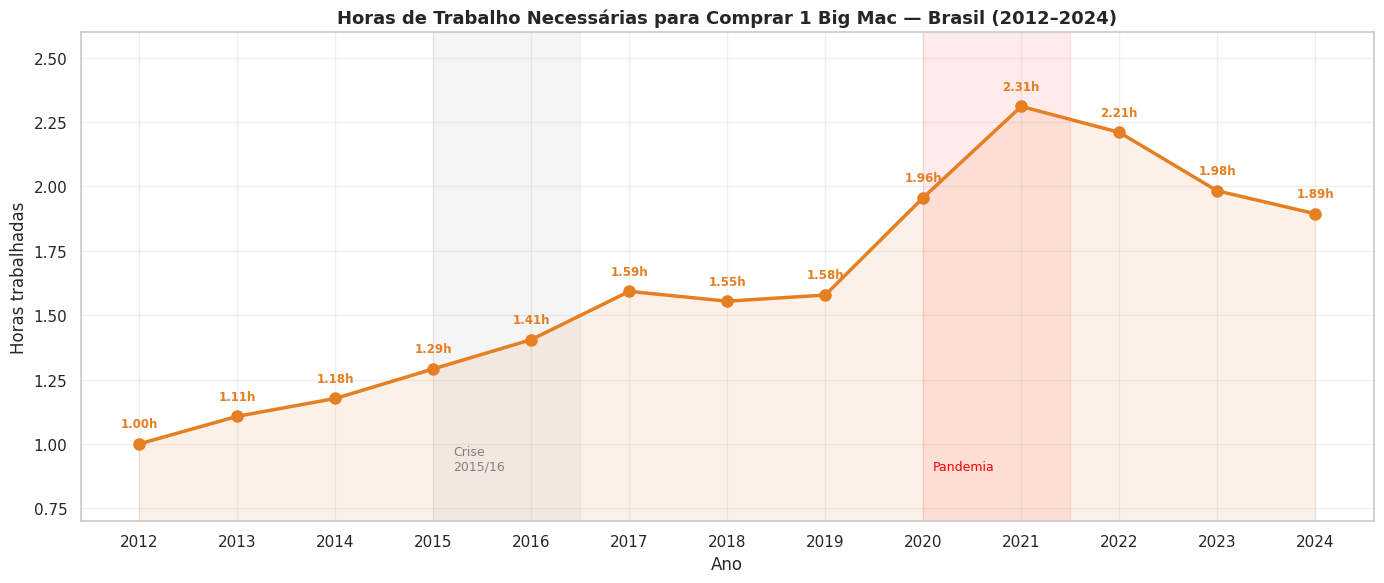

In [ ]:
# ============================================================
# Gráfico 6 — Horas trabalhadas para comprar 1 Big Mac
# Metodologia: jornada padrão de 160h mensais (40h semanais)
# salario_hora = rendimento_medio / 160
# horas_para_bigmac = preco_bigmac_brl / salario_hora
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_horas['ano'], df_horas['horas_para_bigmac'],
        color='#e67e22', linewidth=2.5, marker='o', markersize=8)
ax.fill_between(df_horas['ano'], df_horas['horas_para_bigmac'],
                alpha=0.1, color='#e67e22')

# Anotando cada ponto com o valor
for _, row in df_horas.iterrows():
    ax.annotate(f"{row['horas_para_bigmac']:.2f}h",
               (row['ano'], row['horas_para_bigmac']),
               textcoords='offset points', xytext=(0, 12),
               fontsize=8.5, ha='center', color='#e67e22', fontweight='bold')

# Eventos importantes
ax.axvspan(2015, 2016.5, alpha=0.08, color='gray')
ax.axvspan(2020, 2021.5, alpha=0.08, color='red')
ax.text(2015.2, 0.9, 'Crise\n2015/16', fontsize=9, color='gray')
ax.text(2020.1, 0.9, 'Pandemia', fontsize=9, color='red')

ax.set_title('Horas de Trabalho Necessárias para Comprar 1 Big Mac — Brasil (2012–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Horas trabalhadas')
ax.set_xticks(df_horas['ano'])
ax.set_ylim(0.7, 2.6)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📝 Análise — Gráfico 6

Considerando uma jornada padrão de **160 horas mensais** (40 horas semanais),
dividimos o rendimento domiciliar per capita médio por 160 para obter o
valor da hora trabalhada, e então calculamos quantas horas são necessárias
para comprar um Big Mac.

O resultado é revelador: em **2012**, o trabalhador brasileiro precisava de
**1 hora** de trabalho para comprar um Big Mac. Em **2021**, esse número
chegou a **2,3 horas** — o pior momento do período, combinando o pico do
preço do produto com o menor rendimento domiciliar registrado pós-pandemia.

Em **2024**, mesmo com a recuperação da renda, ainda são necessárias quase
**1,9 horas** de trabalho — praticamente o dobro do valor de 2012. Isso
significa que o custo de vida, medido por este indicador, deteriorou
significativamente ao longo de 12 anos sem que a renda média acompanhasse
o mesmo ritmo.

Os dois eventos que mais pressionaram esse índice foram a **crise de
2015/2016**, que combinou aumento de preços com queda de renda, e a
**pandemia de 2020/2021**, que acelerou os preços enquanto destruía renda
— criando o pior cenário para o poder de compra do trabalhador brasileiro
no período analisado.

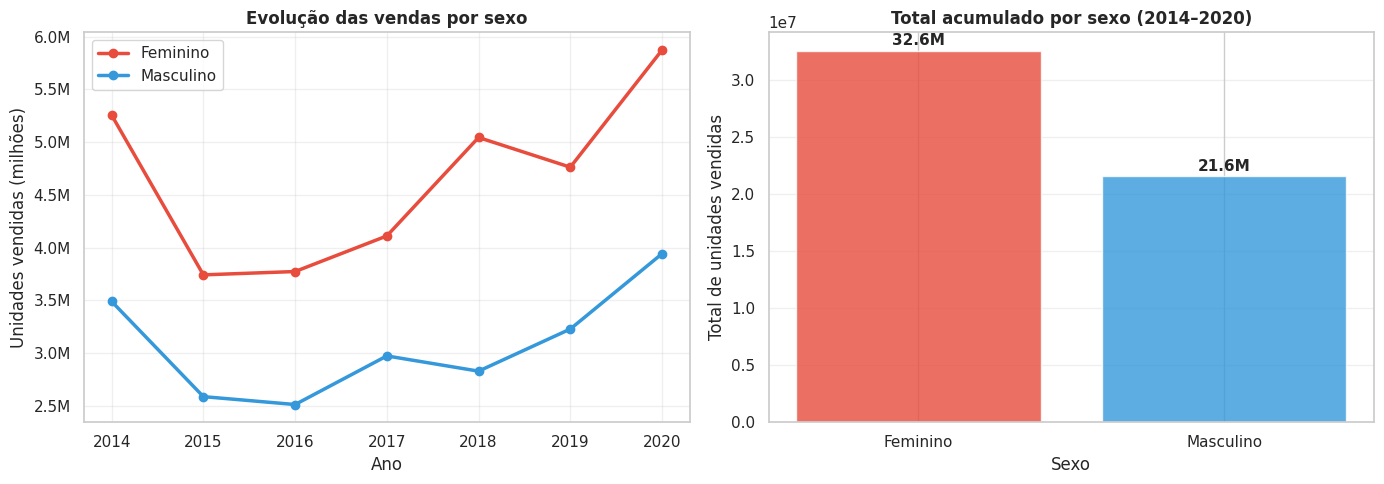

In [ ]:
# ============================================================
# Gráfico 7 — Venda por sexo
# ============================================================

# Converter sexo para legível
df_anvisa['sexo_label'] = df_anvisa['sexo'].map({1: 'Masculino', 2: 'Feminino'})

# Agregar por ano e sexo
df_sexo = df_anvisa.groupby(
    ['ano', 'sexo_label'])['total_vendido'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de linha — evolução temporal
for sexo, cor in [('Feminino', '#e74c3c'), ('Masculino', '#3498db')]:
    dados = df_sexo[df_sexo['sexo_label'] == sexo]
    axes[0].plot(dados['ano'], dados['total_vendido'],
                color=cor, linewidth=2.5, marker='o', markersize=6, label=sexo)

axes[0].set_title('Evolução das vendas por sexo', fontweight='bold')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Unidades vendidas (milhões)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Gráfico de barras — total acumulado
total_sexo = df_anvisa.groupby('sexo_label')['total_vendido'].sum()
axes[1].bar(total_sexo.index, total_sexo.values,
            color=['#e74c3c', '#3498db'], alpha=0.8, edgecolor='white')
axes[1].set_title('Total acumulado por sexo (2014–2020)', fontweight='bold')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Total de unidades vendidas')
for i, (idx, val) in enumerate(total_sexo.items()):
    axes[1].text(i, val + 500000, f'{val/1e6:.1f}M',
                ha='center', fontweight='bold', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 📝 Análise — Gráfico 7

A diferença entre os sexos é expressiva e consistente ao longo de todo
o período: mulheres consumiram **32,6 milhões** de unidades contra
**21,6 milhões** dos homens — uma diferença de **51% a mais**.

Ambos os sexos seguem a mesma tendência: queda em 2015/2016 e recuperação
a partir de 2017, com aceleração em 2020.

**Interpretação com cautela:** seria precipitado concluir que mulheres
sofrem mais de transtornos mentais do que homens apenas com base nesses
dados. Uma hipótese relevante é que essa diferença reflita, ao menos em
parte, o fenômeno amplamente documentado na literatura médica de que
**homens têm maior resistência cultural a buscar ajuda psiquiátrica** —
seja por estigma social ou simplesmente por não
reconhecerem os próprios sintomas.

Isso significa que o consumo masculino de psicofármacos pode estar
**subestimado** em relação à real prevalência de transtornos mentais
nessa população. Uma análise mais completa exigiria cruzar esses dados
com taxas de diagnóstico e acesso a serviços de saúde mental por sexo.

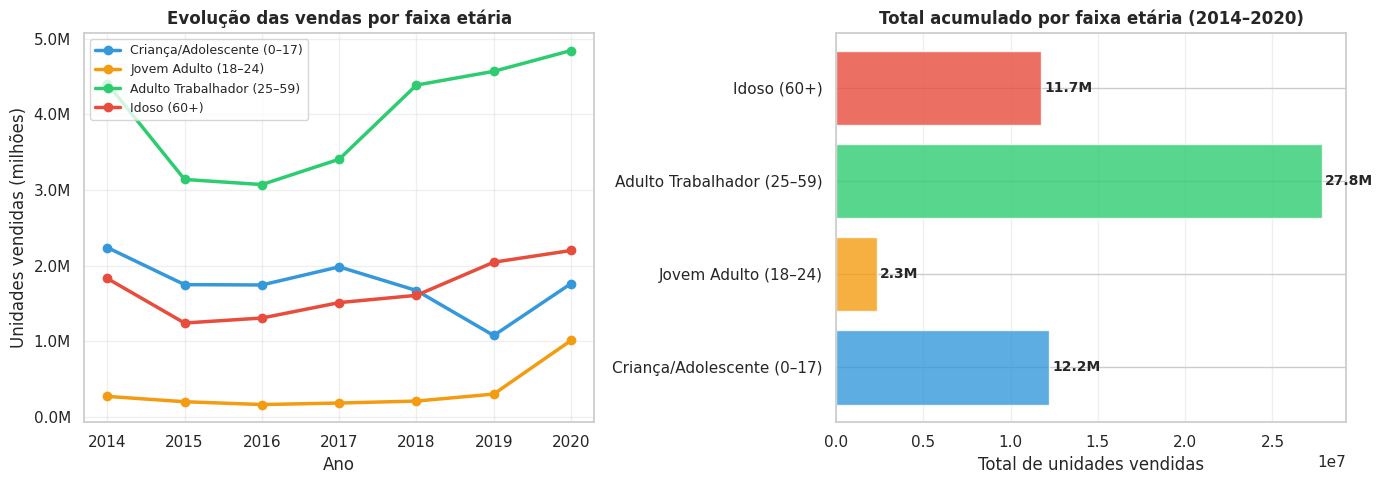

In [ ]:
# ============================================================
# Gráfico 8 — Venda por faixa etária
# ============================================================

df_faixa = df_anvisa.groupby(
    ['ano', 'faixa_etaria'])['total_vendido'].sum().reset_index()

cores_faixa = {
    'ADULTO_TRABALHADOR':   '#2ecc71',
    'IDOSO':                '#e74c3c',
    'CRIANCA_ADOLESCENTE':  '#3498db',
    'JOVEM_ADULTO':         '#f39c12'
}

nomes_faixa = {
    'ADULTO_TRABALHADOR':  'Adulto Trabalhador (25–59)',
    'IDOSO':               'Idoso (60+)',
    'CRIANCA_ADOLESCENTE': 'Criança/Adolescente (0–17)',
    'JOVEM_ADULTO':        'Jovem Adulto (18–24)'
}

# Ordem lógica por idade
ordem = ['CRIANCA_ADOLESCENTE', 'JOVEM_ADULTO', 'ADULTO_TRABALHADOR', 'IDOSO']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de linha — evolução temporal
for faixa in ordem:
    dados = df_faixa[df_faixa['faixa_etaria'] == faixa]
    axes[0].plot(dados['ano'], dados['total_vendido'],
                color=cores_faixa[faixa], linewidth=2.5, marker='o',
                markersize=6, label=nomes_faixa[faixa])

axes[0].set_title('Evolução das vendas por faixa etária', fontweight='bold')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Unidades vendidas (milhões)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Gráfico de barras horizontal — ordenado por faixa etária
total_faixa = df_anvisa.groupby('faixa_etaria')['total_vendido'].sum()
total_faixa = total_faixa.reindex(ordem)
labels = [nomes_faixa[f] for f in ordem]
cores_bar = [cores_faixa[f] for f in ordem]

axes[1].barh(labels, total_faixa.values,
             color=cores_bar, alpha=0.8, edgecolor='white')
axes[1].set_title('Total acumulado por faixa etária (2014–2020)', fontweight='bold')
axes[1].set_xlabel('Total de unidades vendidas')
for i, val in enumerate(total_faixa.values):
    axes[1].text(val + 200000, i, f'{val/1e6:.1f}M',
                va='center', fontweight='bold', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='x')

axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

### 3.7 Correlação: Custo de Vida vs Consumo de Psicofármacos

Cruzamos o preço do Big Mac em dólar (proxy do custo de vida) com o
volume de vendas de psicofármacos para adultos trabalhadores (25–59 anos),
que é a faixa etária mais exposta às pressões econômicas do mercado de trabalho.

**Hipótese:** períodos de maior custo de vida relativo (Big Mac mais caro
em dólar = real mais valorizado = pressão econômica diferente) ou de queda
do rendimento domiciliar estão associados a maior consumo de psicofármacos.

In [ ]:
# ============================================================
# Correlação: Custo de vida vs Psicofármacos (adultos trabalhadores)
# ============================================================

# Agregar ANVISA: apenas adultos trabalhadores, por ano
df_trab = df_anvisa[
    df_anvisa['faixa_etaria'] == 'ADULTO_TRABALHADOR'
].groupby(['ano', 'categoria'])['total_vendido'].sum().reset_index()

# Pivotar para ter uma coluna por categoria
df_trab_pivot = df_trab.pivot(
    index='ano', columns='categoria', values='total_vendido').reset_index()
df_trab_pivot.columns.name = None

# Agregar Big Mac Brasil por ano (média anual)
df_bigmac_anual = df_brasil.groupby('ano')['dollar_price'].mean().reset_index()

# Juntar os três datasets pelo ano
df_corr = df_trab_pivot.merge(df_bigmac_anual, on='ano')
df_corr = df_corr.merge(df_renda, on='ano')

# Filtrar apenas período em comum (2014–2020)
df_corr = df_corr[df_corr['ano'].between(2014, 2020)]

print("=== DATASET CRUZADO ===")
print(df_corr.to_string(index=False))

print("\n=== CORRELAÇÃO DE PEARSON ===")
colunas = ['dollar_price', 'rendimento_medio',
           'ANSIOLITICO', 'ANTIDEPRESSIVO', 'ANTIPSICÓTICO_ESTABILIZADOR']
print(df_corr[colunas].corr().round(3))

=== DATASET CRUZADO ===
 ano  ANSIOLITICO  ANTIDEPRESSIVO  ANTIPSICÓTICO_ESTABILIZADOR  dollar_price  rendimento_medio
2014      1977433         1776234                       652546      5.551326       1726.917733
2015      1451243         1223343                       464110      4.744673       1672.575444
2016      1334453         1241791                       494662      4.068007       1651.186080
2017      1458576         1406688                       540817      5.109756       1657.795482
2018      1485740         2332197                       568148      4.757308       1719.109861
2019      1712796         2022302                       832817      4.570974       1743.729856
2020      1810139         2236431                       796143      4.359043       1668.318822

=== CORRELAÇÃO DE PEARSON ===
                             dollar_price  rendimento_medio  ANSIOLITICO  \
dollar_price                        1.000             0.401        0.487   
rendimento_medio                 

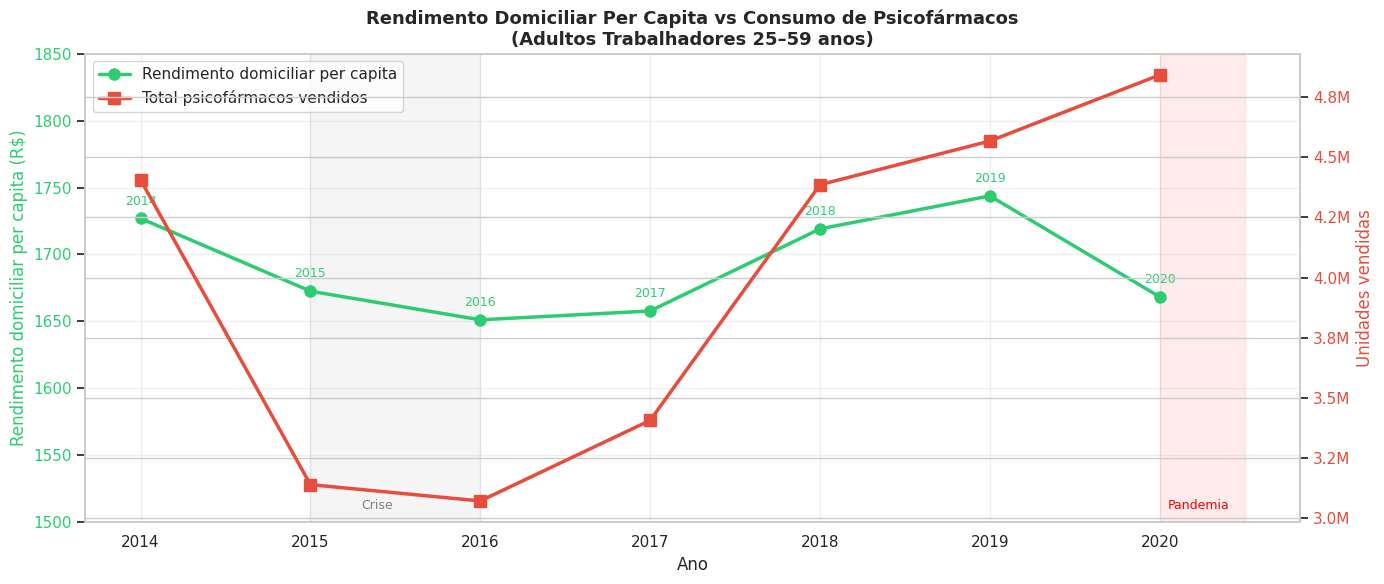

In [ ]:
# ============================================================
# Gráfico 9 — Duplo eixo: Rendimento vs Psicofármacos
# ============================================================

# Total de psicofármacos por ano (adultos trabalhadores)
df_trab_total = df_corr[['ano', 'ANSIOLITICO', 'ANTIDEPRESSIVO',
                          'ANTIPSICÓTICO_ESTABILIZADOR']].copy()
df_trab_total['total_psicofarmacos'] = (
    df_trab_total['ANSIOLITICO'] +
    df_trab_total['ANTIDEPRESSIVO'] +
    df_trab_total['ANTIPSICÓTICO_ESTABILIZADOR']
)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Eixo esquerdo — rendimento
color_renda = '#2ecc71'
ax1.plot(df_corr['ano'], df_corr['rendimento_medio'],
         color=color_renda, linewidth=2.5, marker='o',
         markersize=8, label='Rendimento domiciliar per capita')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Rendimento domiciliar per capita (R$)', color=color_renda)
ax1.tick_params(axis='y', labelcolor=color_renda)
ax1.set_ylim(1500, 1850)

# Eixo direito — psicofármacos
ax2 = ax1.twinx()
color_farm = '#e74c3c'
ax2.plot(df_trab_total['ano'], df_trab_total['total_psicofarmacos'],
         color=color_farm, linewidth=2.5, marker='s',
         markersize=8, label='Total psicofármacos vendidos')
ax2.set_ylabel('Unidades vendidas', color=color_farm)
ax2.tick_params(axis='y', labelcolor=color_farm)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Anotando eventos
for ano, renda, farm in zip(df_corr['ano'],
                             df_corr['rendimento_medio'],
                             df_trab_total['total_psicofarmacos']):
    ax1.annotate(str(ano), (ano, renda),
                textcoords='offset points', xytext=(0, 10),
                fontsize=9, color=color_renda, ha='center')

# Destacando crise e pandemia
ax1.axvspan(2015, 2016, alpha=0.08, color='gray')
ax1.axvspan(2020, 2020.5, alpha=0.08, color='red')
ax1.text(2015.3, 1510, 'Crise', fontsize=9, color='gray')
ax1.text(2020.05, 1510, 'Pandemia', fontsize=9, color='red')

# Legenda unificada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Rendimento Domiciliar Per Capita vs Consumo de Psicofármacos\n(Adultos Trabalhadores 25–59 anos)',
              fontsize=13, fontweight='bold')
ax1.set_xticks(df_corr['ano'])
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📝 Análise — Gráfico 9

Este é o gráfico mais revelador do projeto e evidencia um **paradoxo cruel**
que afeta a classe trabalhadora brasileira.

**2014–2016 — Crise econômica:**
O rendimento domiciliar cai de R\$ 1.727 para R\$ 1.651, e o consumo de
psicofármacos cai junto — de 4,4M para 3,1M de unidades. Isso não significa
que as pessoas ficaram mais saudáveis. Significa que a crise gerou um
**duplo impacto devastador:**
- Por um lado, a instabilidade econômica — desemprego, dívidas, incerteza —
  **intensifica** quadros de ansiedade, depressão e sofrimento psíquico
- Por outro, a queda do poder de compra **reduz o acesso** a medicamentos
  controlados, que têm custo elevado e exigem consultas médicas

O trabalhador que mais precisava de tratamento era exatamente o que menos
conseguia pagar por ele.

**2017–2019 — Recuperação com demanda reprimida:**
Com a leve melhora do rendimento, o consumo dispara — crescendo muito mais
rapidamente que a renda. Isso evidencia que havia uma **enorme demanda
reprimida** durante a crise. Milhões de brasileiros que precisavam de
tratamento finalmente conseguiram acessá-lo quando o orçamento permitiu.

**2020 — Pandemia — O paradoxo em seu ápice:**
O rendimento volta a cair, mas o consumo de psicofármacos atinge seu pico
histórico no período. A pandemia foi tão traumática — isolamento social,
medo da morte, luto, desemprego abrupto, perda de rotina e de sentido de
vida — que **sobrepôs parcialmente a barreira financeira.**

Isso revela o núcleo do paradoxo:
> A queda do rendimento **causa** o sofrimento psíquico ao mesmo tempo
> que **impede** o acesso ao tratamento. Quanto mais o trabalhador precisa
> de ajuda, menos condições financeiras tem para buscá-la.

Este ciclo — sofrimento sem tratamento — tem consequências que vão além
da saúde individual: afeta produtividade, relações familiares, qualidade
de vida e perpetua a desigualdade social.

> ⚠️ **Importante:** correlação não implica causalidade. Este gráfico
> sugere associações que merecem investigação mais aprofundada com dados
> longitudinais e controles estatísticos adequados. Os dados de venda de
> medicamentos refletem apenas farmácias privadas registradas no SNGPC —
> o sistema público de saúde não está representado nesta análise.

## 4. Pré-processamento dos Dados

O objetivo desta etapa é limpar, transformar e preparar os dados para
análise, documentando e justificando cada operação realizada.

As operações aplicadas foram:
1. Remoção do registro com valor zero (Venezuela 2018)
2. Filtragem do Big Mac Index apenas para o Brasil
3. Tratamento de outliers no dataset ANVISA
4. Conversão de tipos de dados (datas, sexo)
5. Criação de variáveis derivadas (dollar_price, ano)
6. Normalização para cruzamento entre datasets

### 4.1 Big Mac Index — limpeza e transformações

In [ ]:
# ============================================================
# PRÉ-PROCESSAMENTO 1 — Big Mac Index
# ============================================================

print(f"Registros antes: {len(df_bigmac)}")

# 1. Remover registro com valor zero (Venezuela 2018)
df_bigmac_clean = df_bigmac[
    (df_bigmac['local_price'] > 0) &
    (df_bigmac['dollar_ex'] > 0)
].copy()
print(f"Registros após remoção de zeros: {len(df_bigmac_clean)}")

# 2. Converter data para datetime
df_bigmac_clean['date'] = pd.to_datetime(df_bigmac_clean['date'])

# 3. Criar coluna dollar_price
df_bigmac_clean['dollar_price'] = (
    df_bigmac_clean['local_price'] / df_bigmac_clean['dollar_ex']
)

# 4. Criar coluna de ano
df_bigmac_clean['ano'] = df_bigmac_clean['date'].dt.year

# 5. Remover colunas não utilizadas
df_bigmac_clean = df_bigmac_clean.drop(columns=['GDP_dollar', 'GDP_local'])

print(f"\nColunas finais: {list(df_bigmac_clean.columns)}")
print(f"Tipos de dados:\n{df_bigmac_clean.dtypes}")
print(f"\n✅ Big Mac Index processado: {len(df_bigmac_clean)} registros")

Registros antes: 2302
Registros após remoção de zeros: 2301

Colunas finais: ['name', 'iso_a3', 'currency_code', 'local_price', 'dollar_ex', 'date', 'dollar_price', 'ano']
Tipos de dados:
name                     object
iso_a3                   object
currency_code            object
local_price             float64
dollar_ex               float64
date             datetime64[ns]
dollar_price            float64
ano                       int32
dtype: object

✅ Big Mac Index processado: 2301 registros


### 4.2 ANVISA Psicofármacos — limpeza e transformações

In [ ]:
# ============================================================
# PRÉ-PROCESSAMENTO 2 — ANVISA Psicofármacos
# ============================================================

print(f"Registros antes: {len(df_anvisa)}")

df_anvisa_clean = df_anvisa.copy()

# 1. Converter sexo de inteiro para categórico legível
df_anvisa_clean['sexo'] = df_anvisa_clean['sexo'].map({
    1: 'Masculino',
    2: 'Feminino'
})

# 2. Identificar e tratar outliers
# Critério: valores acima de média + 2 desvios padrão por categoria/sexo/faixa
def tratar_outliers_mediana(df):
    df_resultado = df.copy()
    grupos = ['categoria', 'sexo', 'faixa_etaria', 'mes']

    for _, grupo in df.groupby(grupos):
        mask = (
            (df_resultado['categoria'] == grupo['categoria'].iloc[0]) &
            (df_resultado['sexo'] == grupo['sexo'].iloc[0]) &
            (df_resultado['faixa_etaria'] == grupo['faixa_etaria'].iloc[0]) &
            (df_resultado['mes'] == grupo['mes'].iloc[0])
        )
        media = grupo['total_vendido'].mean()
        std = grupo['total_vendido'].std()
        limite = media + 2 * std
        mediana = grupo['total_vendido'].median()

        # Substituir outliers pela mediana do grupo
        outlier_mask = mask & (df_resultado['total_vendido'] > limite)
        df_resultado.loc[outlier_mask, 'total_vendido'] = mediana

    return df_resultado

df_anvisa_clean = tratar_outliers_mediana(df_anvisa_clean)

# 3. Criar coluna de data
df_anvisa_clean['data'] = pd.to_datetime(
    df_anvisa_clean['ano'].astype(str) + '-' +
    df_anvisa_clean['mes'].astype(str) + '-01'
)

# 4. Ordenar por data
df_anvisa_clean = df_anvisa_clean.sort_values(
    ['data', 'categoria', 'sexo', 'faixa_etaria']
).reset_index(drop=True)

print(f"Registros após tratamento: {len(df_anvisa_clean)}")
print(f"\nValor máximo antes: 876.797")
print(f"Valor máximo após:  {df_anvisa_clean['total_vendido'].max():,}")
print(f"\nColunas finais: {list(df_anvisa_clean.columns)}")
print(f"\n✅ ANVISA processado: {len(df_anvisa_clean)} registros")

Registros antes: 2016
Registros após tratamento: 2016

Valor máximo antes: 876.797
Valor máximo após:  136,597

Colunas finais: ['ano', 'mes', 'sexo', 'faixa_etaria', 'categoria', 'total_vendido', 'sexo_label', 'data']

✅ ANVISA processado: 2016 registros


### 4.3 Rendimento Domiciliar e Ansiedade — verificação

Estes datasets já chegaram limpos e estruturados. As transformações
necessárias foram realizadas no momento do carregamento:
- Rendimento: transposição de formato horizontal para vertical
- Ansiedade: extração de coordenadas SVG e conversão para percentual

Apenas verificamos a consistência final.

In [ ]:
# ============================================================
# PRÉ-PROCESSAMENTO 3 — Rendimento e Ansiedade
# ============================================================

# Rendimento — já processado no carregamento
df_renda_clean = df_renda.copy()
df_renda_clean.columns = ['ano', 'rendimento_medio']

# Ansiedade — já processado no carregamento
df_ansiedade_clean = df_ansiedade.copy()
df_ansiedade_clean.columns = ['ano', 'anxiety_prevalence_pct']

print("=== RENDIMENTO DOMICILIAR ===")
print(f"Período: {df_renda_clean['ano'].min()} – {df_renda_clean['ano'].max()}")
print(f"Nulos: {df_renda_clean.isnull().sum().sum()}")
print(f"✅ Pronto: {len(df_renda_clean)} registros")

print("\n=== ANSIEDADE BRASIL ===")
print(f"Período: {df_ansiedade_clean['ano'].min()} – {df_ansiedade_clean['ano'].max()}")
print(f"Nulos: {df_ansiedade_clean.isnull().sum().sum()}")
print(f"✅ Pronto: {len(df_ansiedade_clean)} registros")

=== RENDIMENTO DOMICILIAR ===
Período: 2012 – 2024
Nulos: 0
✅ Pronto: 13 registros

=== ANSIEDADE BRASIL ===
Período: 1990 – 2023
Nulos: 0
✅ Pronto: 34 registros
